K=3, Accuracy=1.00


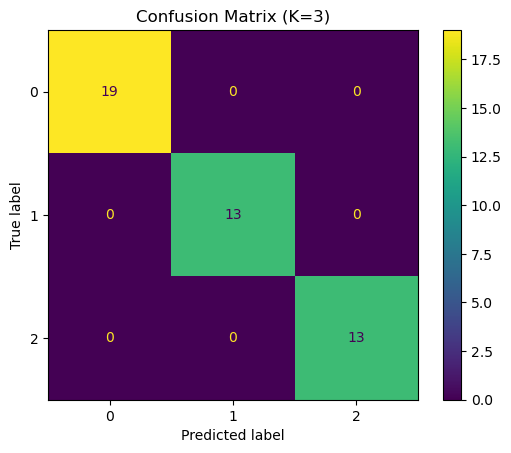

K=5, Accuracy=1.00


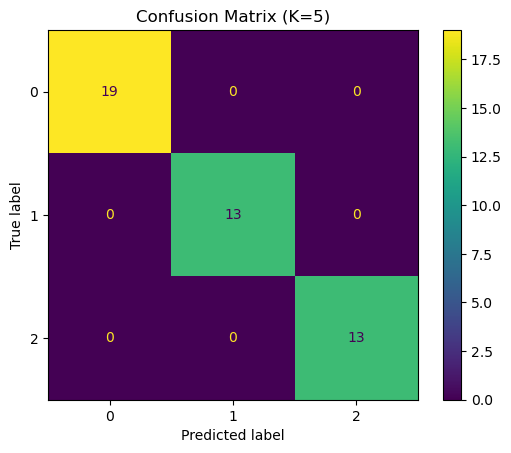

K=7, Accuracy=1.00


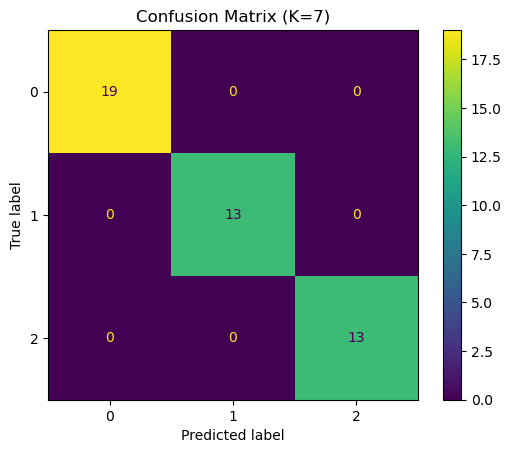

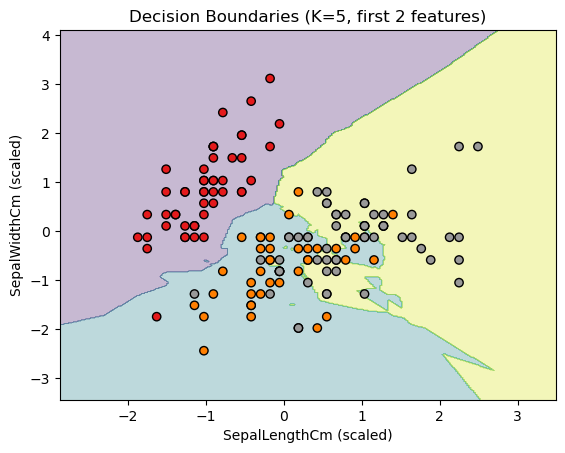

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# Load dataset
df = pd.read_csv(r"C:\Users\Thrishaa J\Downloads\Iris.csv")
df = df.drop('Id', axis=1)  # Drop ID column if present

# Encode target
df['Species'] = df['Species'].astype('category').cat.codes

# Features and target
X = df.drop('Species', axis=1)
y = df['Species']

# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

# Try different K values
k_values = [3, 5, 7]
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f'K={k}, Accuracy={acc:.2f}')
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f'Confusion Matrix (K={k})')
    plt.show()

# Visualize decision boundaries (using first two features)
def plot_decision_boundaries(X, y, model, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3)
    scatter = plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor='k', cmap=plt.cm.Set1)
    plt.xlabel('SepalLengthCm (scaled)')
    plt.ylabel('SepalWidthCm (scaled)')
    plt.title(title)
    plt.show()

# Use only first two features
X_two = X_scaled[:, :2]
X_train2, X_test2, y_train2, y_test2 = train_test_split(X_two, y, test_size=0.3, random_state=42)

knn2 = KNeighborsClassifier(n_neighbors=5)
knn2.fit(X_train2, y_train2)
plot_decision_boundaries(X_two, y, knn2, 'Decision Boundaries (K=5, first 2 features)')